# UNIVERSIDAD AUTONOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computacion
## Carrera: Ingenieria en Computacion Inteligente

**Curso:** Machine y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** Guillermo González Lara (237864)
**Semestre:** Enero-Junio del 2026

---

# Practica No. 35 - Componentes de Series de Tiempo y Regresion Lineal (Python)

En esta practica se estudian los componentes de una serie de tiempo (tendencia, ciclicidad, estacionalidad y movimiento aleatorio) usando el dataset stockdata.csv. Ademas, se aplica una regresion lineal simple para observar la tendencia.

Modelo aditivo: $y_t = T_t + C_t + S_t + R_t$

## Paso 1: Instalacion e importacion de librerias

In [5]:
# Instalacion de dependencias necesarias
!pip install pandas numpy matplotlib statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from pathlib import Path
from IPython.display import display

plt.style.use("seaborn-v0_8-darkgrid")
print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Paso 2: Cargar y preparar los datos

Se lee el archivo con separador `;` y decimales con coma. La fecha se convierte a formato datetime y se ordena la serie.

In [6]:
data_path = Path("stockdata.csv")
df = pd.read_csv(data_path, sep=";", decimal=",")
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")

num_cols = ["open", "high", "low", "close", "volume"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

df = df.sort_values("date").set_index("date")
df = df.dropna(subset=["close"])

display(df.head())
display(df.describe())

,open,high,low,close,volume
date,,,,,
2000-01-03,58.25,58.50,51.87,52.25,860595
2000-01-04,52.91,54.68,52.30,52.80,542879
2000-01-05,52.00,54.85,51.53,52.42,547589
2000-01-06,52.55,54.50,52.45,53.02,353360
2000-01-07,53.90,54.88,53.06,54.76,661661


,open,high,low,close,volume
count,589.000000,589.000000,589.000000,589.000000,5.890000e+02
mean,37.053616,37.696469,36.300000,36.953192,5.468570e+05
std,6.304780,6.330394,6.221932,6.221486,4.695923e+05
min,19.000000,21.000000,17.150000,19.200000,7.323900e+04
25%,33.300000,33.980000,32.860000,33.400000,3.499070e+05
50%,36.620000,37.340000,36.000000,36.560000,4.484160e+05
75%,40.320000,40.690000,39.530000,40.010000,6.181370e+05
max,58.250000,58.500000,54.440000,55.280000,7.031178e+06


## Paso 3: Visualizar la serie de tiempo (precio de cierre)

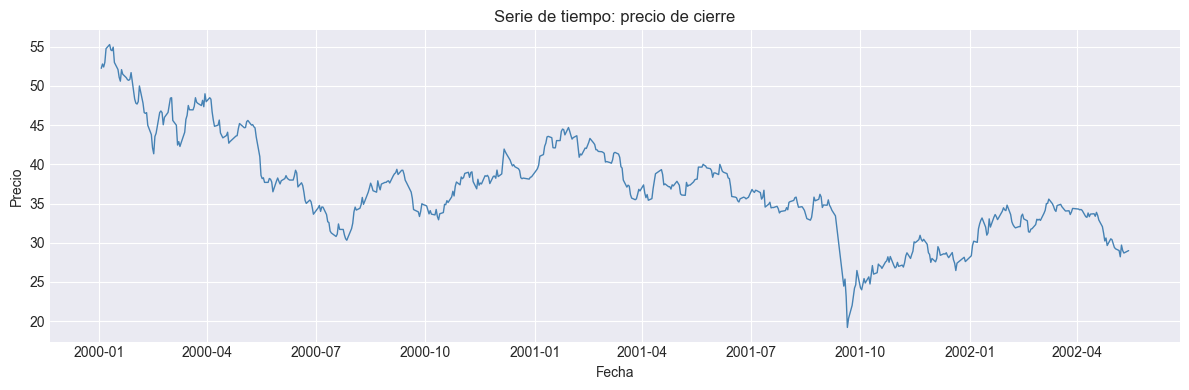

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["close"], color="steelblue", linewidth=1)
plt.title("Serie de tiempo: precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()

## Paso 4: Crear serie mensual para analizar estacionalidad

La estacionalidad se observa mejor en una serie con frecuencia regular. Aqui se usa el promedio mensual del precio de cierre.

In [8]:
monthly_close = df["close"].resample("ME").mean().dropna()
print(f"Observaciones mensuales: {len(monthly_close)}")
monthly_close.head()

Observaciones mensuales: 29


date
2000-01-31    52.307143
2000-02-29    45.998571
2000-03-31    46.393913
2000-04-30    44.786667
2000-05-31    40.883636
Freq: ME, Name: close, dtype: float64

## Paso 5: Descomposicion STL (tendencia y estacionalidad)

Se usa STL con periodo 12 para separar tendencia, estacionalidad y residuo.

In [9]:
stl = STL(monthly_close, period=12, robust=True)
stl_result = stl.fit()

components = pd.DataFrame({
    "observed": monthly_close,
    "trend": stl_result.trend,
    "seasonal": stl_result.seasonal,
    "resid": stl_result.resid
})

components.head()

,observed,trend,seasonal,resid
date,,,,
2000-01-31,52.307143,43.234468,9.141428,-0.068752
2000-02-29,45.998571,42.774458,3.261371,-0.037257
2000-03-31,46.393913,42.313624,4.110397,-0.030108
2000-04-30,44.786667,41.851936,2.957424,-0.022694
2000-05-31,40.883636,41.389360,-0.490682,-0.015041


## Paso 6: Ciclicidad y movimiento aleatorio

La ciclicidad se obtiene como una version suavizada de las desviaciones respecto a la tendencia (ya sin estacionalidad). El movimiento aleatorio es el residuo restante.

$y_t = T_t + S_t + C_t + R_t$

In [10]:
deseasonal = components["observed"] - components["seasonal"]
cycle_raw = deseasonal - components["trend"]

cycle = cycle_raw.rolling(window=6, center=True, min_periods=3).mean()
random = cycle_raw - cycle

components["cycle"] = cycle
components["random"] = random

components[["trend", "seasonal", "cycle", "random"]].head()

,trend,seasonal,cycle,random
date,,,,
2000-01-31,43.234468,9.141428,-0.045372,-0.023380
2000-02-29,42.774458,3.261371,-0.039703,0.002446
2000-03-31,42.313624,4.110397,-0.034770,0.004662
2000-04-30,41.851936,2.957424,-0.030185,0.007492
2000-05-31,41.389360,-0.490682,-0.018638,0.003597


## Paso 7: Graficas de componentes

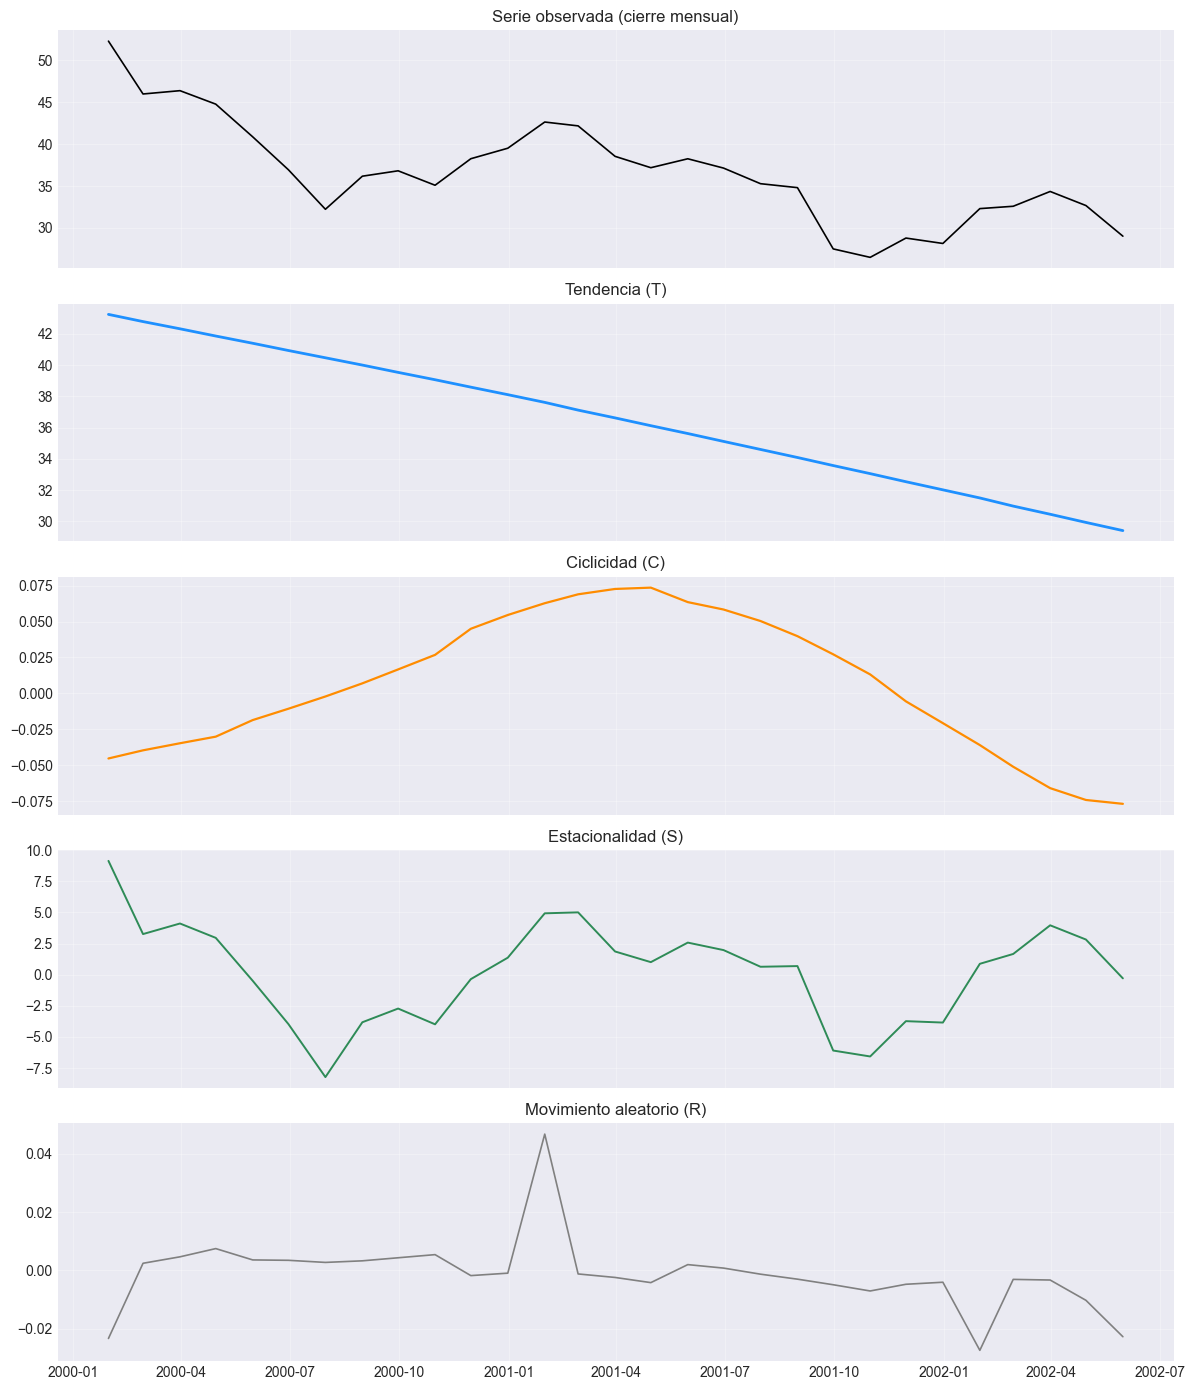

In [11]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

axes[0].plot(components.index, components["observed"], color="black", linewidth=1.2)
axes[0].set_title("Serie observada (cierre mensual)")

axes[1].plot(components.index, components["trend"], color="dodgerblue", linewidth=2)
axes[1].set_title("Tendencia (T)")

axes[2].plot(components.index, components["cycle"], color="darkorange", linewidth=1.6)
axes[2].set_title("Ciclicidad (C)")

axes[3].plot(components.index, components["seasonal"], color="seagreen", linewidth=1.4)
axes[3].set_title("Estacionalidad (S)")

axes[4].plot(components.index, components["random"], color="gray", linewidth=1.2)
axes[4].set_title("Movimiento aleatorio (R)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 8: Regresion lineal para observar la tendencia

Se ajusta un modelo lineal simple sobre el tiempo: $y_t = \beta_0 + \beta_1 t$.

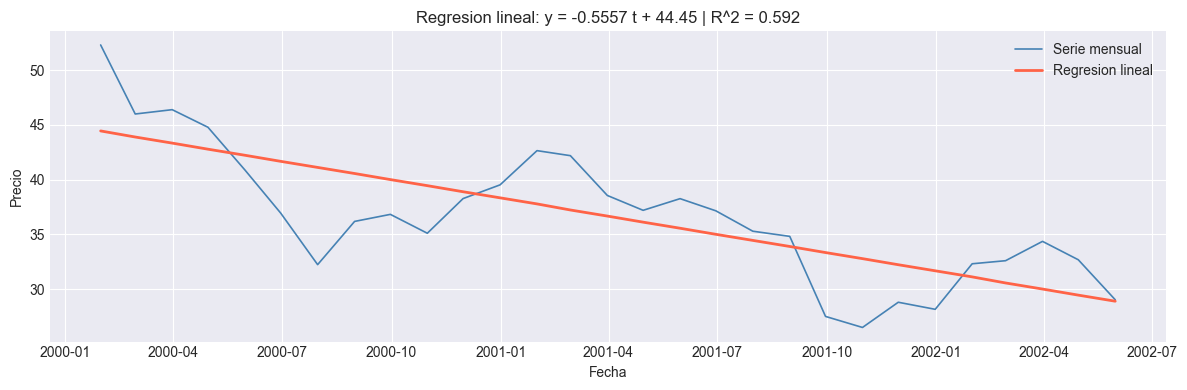

In [12]:
t = np.arange(len(monthly_close))
y = monthly_close.values

m, b = np.polyfit(t, y, 1)
y_hat = m * t + b

ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

plt.figure(figsize=(12, 4))
plt.plot(monthly_close.index, y, label="Serie mensual", color="steelblue", linewidth=1.2)
plt.plot(monthly_close.index, y_hat, label="Regresion lineal", color="tomato", linewidth=2)
plt.title(f"Regresion lineal: y = {m:.4f} t + {b:.2f} | R^2 = {r2:.3f}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.tight_layout()
plt.show()

---
# Conclusiones

- La descomposicion STL permite observar de forma separada la tendencia y la estacionalidad.
- La componente ciclica se obtiene al suavizar las desviaciones alrededor de la tendencia y sin estacionalidad.
- El movimiento aleatorio representa el ruido que no es explicado por tendencia, estacionalidad o ciclo.
- La regresion lineal resume la tendencia global y facilita comparar su pendiente entre periodos.

## Referencias
1. Stockdata.csv (dataset proporcionado en el curso)
2. Statsmodels Documentation - STL Decomposition
3. McKinney, W. (2022). Python for Data Analysis, 3rd ed.